## Random Imputation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Titanic Missing Data .csv" , usecols = ["Survived" , "Age" ,"Fare"])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [47]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [48]:
X= df.iloc[:,1:]
y =df.iloc[:,0]

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [50]:
X_train["Imputed Age"] = df["Age"]
X_test["Imputed Age"] = df["Age"]

In [51]:
X_train.head()

,Age,Fare,Imputed Age
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [52]:
X_train["Imputed Age"][X_train["Imputed Age"].isnull()]    # df["Age"][df["Age"] == 10]

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Imputed Age, Length: 148, dtype: float64

In [53]:
X_train.loc[X_train["Imputed Age"].isnull(), "Imputed Age"] = X_train["Age"].dropna().sample(X_train["Age"].isnull().sum()).values
X_test.loc[X_test["Imputed Age"].isnull(), "Imputed Age"] = X_train["Age"].dropna().sample(X_test["Age"].isnull().sum()).values
# df.loc[mask, column_name]

In [54]:
X_train

,Age,Fare,Imputed Age
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,34.0
493,71.0,49.5042,71.0
527,NaN,221.7792,18.0


In [34]:
sample = sampler.sample(X_train["Age"].isnull().sum(),replace = True).values

In [31]:
sampler = pd.DataFrame([1,2,3,4,5])
sampler

,0
0,1
1,2
2,3
3,4
4,5


C:\Users\asifb\AppData\Local\Temp\ipykernel_20508\2608481014.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"] , label ="Orignal" , hist =False )
C:\Users\asifb\AppData\Local\Temp\ipykernel_20508\2608481014.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_

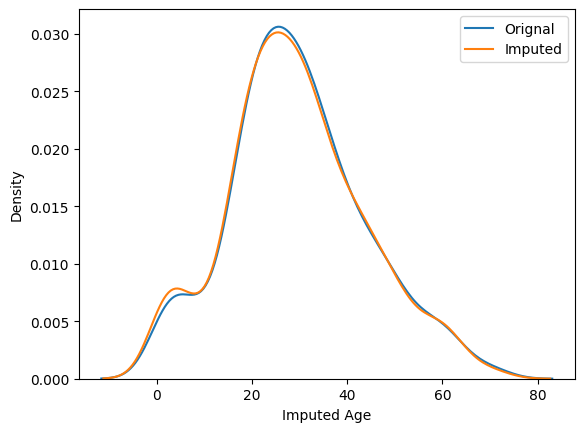

In [58]:
sns.distplot(X_train["Age"] , label ="Orignal" , hist =False )
sns.distplot(X_train["Imputed Age"] , label = "Imputed" , hist= False)
plt.legend()
plt.show()

In [59]:
X_train["Age"].var() , X_train["Imputed Age"].var()

(np.float64(204.34951339046142), np.float64(208.38318049570157))

<Axes: >

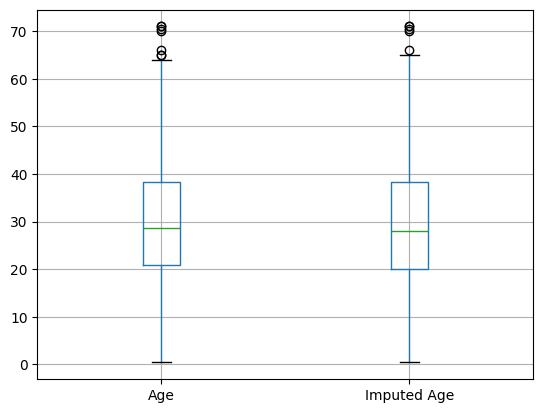

In [62]:
X_train[["Age", "Imputed Age"]].boxplot()

In [63]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Train Data .csv" , usecols = ["GarageQual" , "FireplaceQu" , "SalePrice"] )
df.head()


,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [65]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [67]:
X = df
y = df['SalePrice']

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [69]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [71]:
X_train.head()

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd


In [74]:
X_train.loc[X_train["GarageQual_imputed"].isnull() , "GarageQual_imputed"] = X_train["GarageQual_imputed"].dropna().sample(X_train["GarageQual_imputed"].isnull().sum()).values        

In [81]:
X_train[X_train["GarageQual"].isnull()]

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
127,TA,NaN,87000,TA,TA
99,NaN,NaN,128950,TA,NaN
921,NaN,NaN,145900,Fa,NaN
1179,Gd,NaN,93000,TA,Gd
1143,NaN,NaN,80000,TA,NaN
...,...,...,...,...,...
434,NaN,NaN,81000,TA,NaN
942,NaN,NaN,150000,TA,NaN
1326,NaN,NaN,79000,TA,NaN
1349,NaN,NaN,122000,TA,NaN


## Missing Indicator 

In [9]:
from sklearn.impute import MissingIndicator,SimpleImputer

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [10]:
SI = SimpleImputer()

In [14]:
SI.fit(X_train)
X_trained = SI.transform(X_train)
X_tested = SI.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
Model = LogisticRegression()
Model.fit(X_trained , y_train)
pred = Model.predict(X_tested)

In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.6145251396648045

In [19]:
MI =MissingIndicator()

In [30]:
MI.fit(X_train)
MI.fit(X_test)

,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"features features: {'missing-only', 'all'}, default='missing-only'Whether the imputer mask should represent all or a subset offeatures.- If `'missing-only'` (default), the imputer mask will only represent features containing missing values during fit time.- If `'all'`, the imputer mask will represent all features.",'missing-only'
,"sparse sparse: bool or 'auto', default='auto'Whether the imputer mask format should be sparse or dense.- If `'auto'` (default), the imputer mask will be of same type as input.- If `True`, the imputer mask will be a sparse matrix.- If `False`, the imputer mask will be a numpy array.",'auto'
,"error_on_new error_on_new: bool, default=TrueIf `True`, :meth:`transform` will raise an error when there arefeatures with missing values that have no missing values in:meth:`fit`. This is applicable only when `features='missing-only'`.",True


In [31]:
MI.features_     # column 1 of X_train which is age (this column has missing values)

array([0])

In [35]:
# Age_missing = MI.transform(X_train)

In [37]:
Age_missingt = MI.transform(X_test)

In [27]:
X_train["Age Missing"] = Age_missing 

In [49]:
X_test["Age Missing"] = Age_missingt

In [50]:
X_test.head()    # value hai to false / nahi hai tu true

,Age,Fare,Age Missing
707,42.0,26.2875,False
37,21.0,8.0500,False
615,24.0,65.0000,False
169,28.0,56.4958,False
68,17.0,7.9250,False


In [45]:
SI = SimpleImputer()

In [52]:
SI.fit(X_train)
X_trained  = SI.transform(X_train)
X_tested = SI.transform(X_test)

Model.fit(X_trained,y_train)
y_pred = Model.predict(X_tested)
accuracy_score(y_test , y_pred) 

0.6312849162011173

In [54]:
SI = SimpleImputer(add_indicator = True)

In [56]:
SI.fit(X_train)
X_trained = SI.transform(X_train)
X_tested = SI.transform(X_test)
Model.fit(X_trained, y_train)
y_pred  = Model.predict(X_tested)

accuracy_score(y_test, y_pred)

0.6312849162011173

In [59]:
X_trained = pd.DataFrame(X_trained, columns = ["one","two","three"])
X_trained.head()

,one,two,three
0,40.0,27.7208,0.0
1,4.0,16.7000,0.0
2,47.0,9.0000,0.0
3,9.0,31.3875,0.0
4,20.0,9.8458,0.0
